#### Install

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00a 0:00:01


#### Seed, Plot, Multi-seed

In [2]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.utils import to_undirected
from torch_geometric.nn import GATv2Conv

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def plot_learning_curves(history: dict, model_name: str = "Model") -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.plot(epochs, history['train_loss'], label='Train Loss')
    ax.plot(epochs, history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} – Loss')
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    ax.plot(epochs, history['train_f1'], label='Train F1 (illicit)')
    ax.plot(epochs, history['val_f1'], label='Val F1 (illicit)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1-score')
    ax.set_title(f'{model_name} – F1 (illicit)')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

def run_multiseed(run_single_seed_fn, exp_name="Experiment", seeds=[42, 0, 123]):
    results = []
    for seed in seeds:
        print(f"\n{exp_name} - Seed: {seed}")
        metrics = run_single_seed_fn(seed)
        metrics['seed'] = seed
        results.append(metrics)
        
    print(f"\n {exp_name} multi-seed results")
    metric_keys = [k for k in results[0].keys() if k != 'seed']
    
    for key in metric_keys:
        values = [res[key] for res in results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        
        display_key = {'f1_ill': 'F1(illicit)', 'precision': 'Precision', 'recall': 'Recall', 'auc_pr': 'AUC-PR'}.get(key, key.capitalize())
        print(f"{display_key:<11}: {mean_val:.4f} ± {std_val:.4f}")
        
    return results


#### Integrate data processing logic and GAT model architecture

In [3]:
def load_and_preprocess_data(data_path: str, device: torch.device | None = None, undirected: bool = True) -> tuple:
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    data = torch.load(data_path, weights_only=False)
    
    if undirected:
        data.edge_index = to_undirected(data.edge_index)

    train_features = data.x[data.train_mask]
    train_mean = train_features.mean(dim=0)
    train_std = train_features.std(dim=0)
    data.x = (data.x - train_mean) / (train_std + 1e-8)
    print(data)
    
    data = data.to(device)
    return data, device

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

#### Consolidate model evaluation and early stopping loops

In [4]:
def compute_class_weights(data, device: torch.device) -> torch.Tensor:
    n_licit = (data.y[data.train_mask] == 0).sum().item()
    n_illicit = (data.y[data.train_mask] == 1).sum().item()
    weight = torch.tensor([1.0, math.sqrt(n_licit / n_illicit)], dtype=torch.float).to(device)
    return weight

def evaluate(model, data, criterion, mask) -> dict:
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        probs = F.softmax(out[mask], dim=1)[:, 1]
        y_true, y_pred, y_prob = data.y[mask].cpu().numpy(), pred.cpu().numpy(), probs.cpu().numpy()
        loss = criterion(out[mask], data.y[mask]).item()

    return {
        'loss': loss, 'accuracy': accuracy_score(y_true, y_pred),
        'precision_ill': precision_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'recall_ill': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_ill': f1_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0), 
        'auc_pr': average_precision_score(y_true, y_prob),
    }

def train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=None):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    if clip_grad_norm is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
    optimizer.step()
    return loss.item()

def train_with_early_stopping(model, data, optimizer, criterion, save_path: str, num_epochs: int = 200, patience: int = 20, monitor_metric: str = 'f1_ill', clip_grad_norm=None, scheduler=None) -> dict:
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_score, epochs_no_improve, best_epoch = 0.0, 0, 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=clip_grad_norm)
        train_metrics = evaluate(model, data, criterion, data.train_mask)
        val_metrics = evaluate(model, data, criterion, data.val_mask)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_f1'].append(train_metrics['f1_ill'])
        history['val_f1'].append(val_metrics['f1_ill'])

        if scheduler is not None: scheduler.step()

        if val_metrics[monitor_metric] > best_val_score:
            best_val_score, best_epoch, epochs_no_improve = val_metrics[monitor_metric], epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Val Loss={val_metrics['loss']:.4f}, Train F1={train_metrics['f1_ill']:.4f}, Val F1={val_metrics['f1_ill']:.4f}, Gap={train_metrics['f1_ill'] - val_metrics['f1_ill']:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (Best epoch: {best_epoch})")
            break
    return history

def print_test_evaluation(model, data, criterion, label: str = "Test") -> None:
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    print(f"{label}\n  Loss          : {test_metrics['loss']:.4f}\n  Accuracy      : {test_metrics['accuracy']:.4f}\n  Precision(ill): {test_metrics['precision_ill']:.4f}\n  Recall(ill)   : {test_metrics['recall_ill']:.4f}\n  F1(illicit)   : {test_metrics['f1_ill']:.4f}\n  F1(macro)     : {test_metrics['f1_macro']:.4f}\n  AUC-PR        : {test_metrics['auc_pr']:.4f}")

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1)
        y_true, y_pred = data.y[data.test_mask].cpu().numpy(), pred.cpu().numpy()

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)'], digits=4, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


#### Implement main execution block pointing to Kaggle dataset paths

Device: cuda
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Start training GAT on Kaggle

GAT - Seed: 42
GAT Train - Seed: 42
Epoch 001: Train Loss=1.1621, Val Loss=0.8104, Train F1=0.2795, Val F1=0.1794, Gap=0.1001
Epoch 002: Train Loss=1.5238, Val Loss=0.8098, Train F1=0.2816, Val F1=0.1839, Gap=0.0977
Epoch 003: Train Loss=1.2101, Val Loss=0.8092, Train F1=0.2866, Val F1=0.1895, Gap=0.0972
Epoch 004: Train Loss=1.3014, Val Loss=0.8087, Train F1=0.2904, Val F1=0.1946, Gap=0.0958
Epoch 005: Train Loss=1.1555, Val Loss=0.8083, Train F1=0.2954, Val F1=0.1962, Gap=0.0992
Epoch 006: Train Loss=1.1939, Val Loss=0.8079, Train F1=0.2984, Val F1=0.1985, Gap=0.0999
Epoch 007: Train Loss=1.2212, Val Loss=0.8076, Train F1=0.3031, Val F1=0.2016, Gap=0.1015
Epoch 008: Train Loss=1.2497, Val Loss=0.8072, Train F1=0.3055, Val F1=0.2040, Gap=0.1015
Epoch 009: Train Loss=1.2552, Val Loss=0.8067, Train F1=0.3086, Val F1=0.2067, Gap=

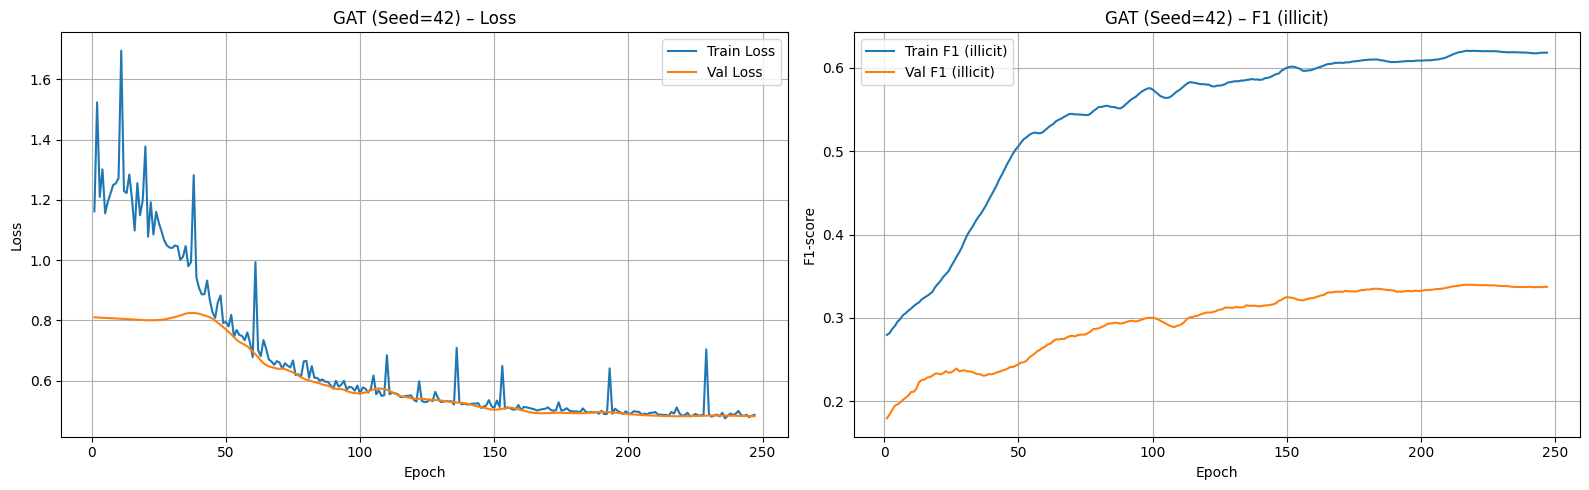

GAT Test - Seed: 42
  Loss          : 0.5314
  Accuracy      : 0.6879
  Precision(ill): 0.2217
  Recall(ill)   : 0.8905
  F1(illicit)   : 0.3550
  F1(macro)     : 0.5746
  AUC-PR        : 0.5328

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9828    0.6662    0.7941      5132
 Illicit (1)     0.2217    0.8905    0.3550       548

    accuracy                         0.6879      5680
   macro avg     0.6022    0.7784    0.5746      5680
weighted avg     0.9093    0.6879    0.7517      5680

Confusion Matrix:
 [[3419 1713]
 [  60  488]]

GAT - Seed: 0
GAT Train - Seed: 0
Epoch 001: Train Loss=1.2217, Val Loss=0.8072, Train F1=0.2470, Val F1=0.1589, Gap=0.0881
Epoch 002: Train Loss=1.2674, Val Loss=0.8070, Train F1=0.2475, Val F1=0.1616, Gap=0.0859
Epoch 003: Train Loss=1.2231, Val Loss=0.8067, Train F1=0.2482, Val F1=0.1640, Gap=0.0843
Epoch 004: Train Loss=1.2729, Val Loss=0.8065, Train F1=0.2488, Val F1=0.1657, Gap=0.0830
Epoch 005: T

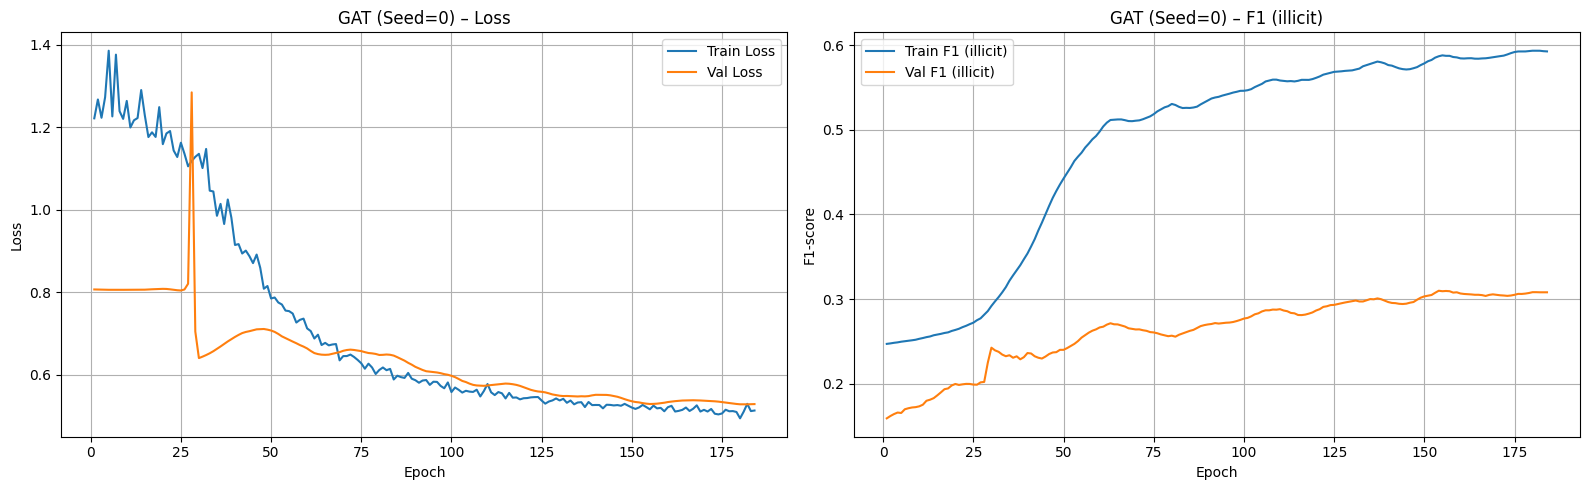

GAT Test - Seed: 0
  Loss          : 0.5833
  Accuracy      : 0.6340
  Precision(ill): 0.1944
  Recall(ill)   : 0.8887
  F1(illicit)   : 0.3190
  F1(macro)     : 0.5344
  AUC-PR        : 0.4707

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9808    0.6068    0.7497      5132
 Illicit (1)     0.1944    0.8887    0.3190       548

    accuracy                         0.6340      5680
   macro avg     0.5876    0.7477    0.5344      5680
weighted avg     0.9049    0.6340    0.7082      5680

Confusion Matrix:
 [[3114 2018]
 [  61  487]]

GAT - Seed: 123
GAT Train - Seed: 123
Epoch 001: Train Loss=1.5244, Val Loss=1.4960, Train F1=0.2950, Val F1=0.1697, Gap=0.1253
Epoch 002: Train Loss=1.6296, Val Loss=1.4923, Train F1=0.2956, Val F1=0.1699, Gap=0.1258
Epoch 003: Train Loss=1.5540, Val Loss=1.4893, Train F1=0.2961, Val F1=0.1699, Gap=0.1263
Epoch 004: Train Loss=1.8418, Val Loss=1.4866, Train F1=0.2967, Val F1=0.1699, Gap=0.1268
Epoch 005

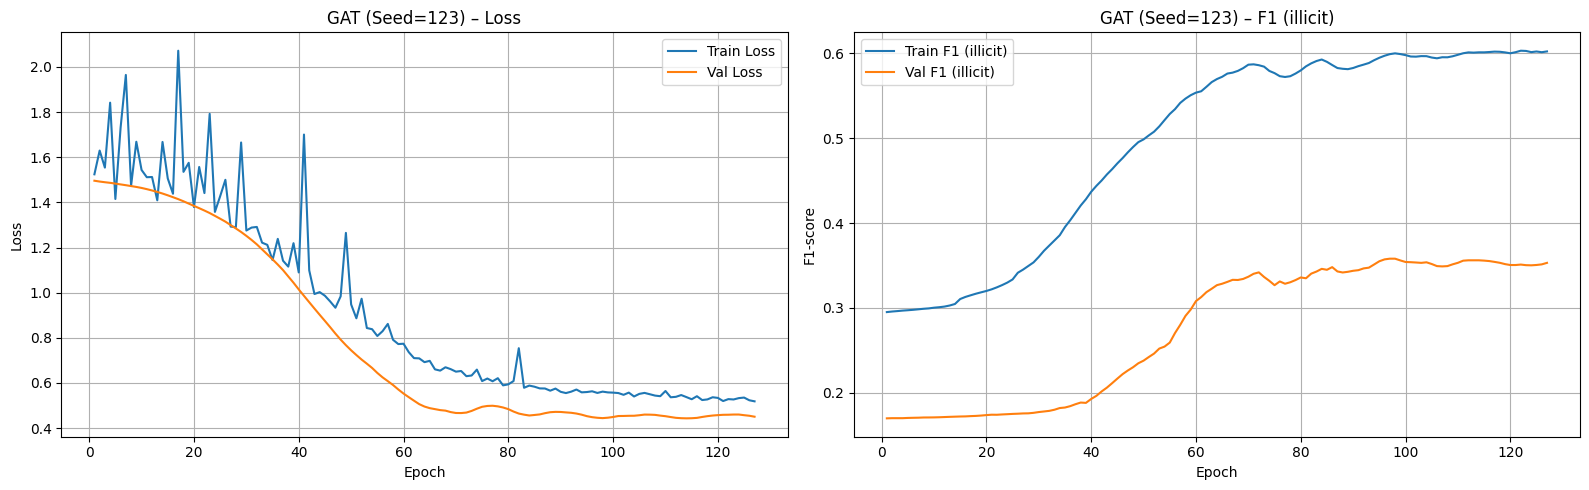

GAT Test - Seed: 123
  Loss          : 0.4525
  Accuracy      : 0.7317
  Precision(ill): 0.2508
  Recall(ill)   : 0.8960
  F1(illicit)   : 0.3919
  F1(macro)     : 0.6099
  AUC-PR        : 0.5360

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9847    0.7141    0.8279      5132
 Illicit (1)     0.2508    0.8960    0.3919       548

    accuracy                         0.7317      5680
   macro avg     0.6177    0.8051    0.6099      5680
weighted avg     0.9139    0.7317    0.7858      5680

Confusion Matrix:
 [[3665 1467]
 [  57  491]]

 GAT multi-seed results
Loss       : 0.5224 ± 0.0538
Accuracy   : 0.6845 ± 0.0400
Precision_ill: 0.2223 ± 0.0230
Recall_ill : 0.8917 ± 0.0031
F1(illicit): 0.3553 ± 0.0297
F1_macro   : 0.5729 ± 0.0308
AUC-PR     : 0.5132 ± 0.0301


In [5]:
data_path = '/kaggle/input/datasets/meowll/elliptic-graph-data/elliptic_pyg_data.pt'

data, device = load_and_preprocess_data(data_path, undirected=False)

def run_single_gcn_seed(seed):
    torch.cuda.empty_cache()
    set_seed(seed)
    print(f"GAT Train - Seed: {seed}")
    
    model = GAT(
        in_channels=data.x.shape[1], 
        hidden_channels=64,
        out_channels=2, 
        heads=2,  
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.001, steps_per_epoch=1, epochs=300, pct_start=0.3,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'/kaggle/working/gat_best_seed_{seed}.pt'
    
    history = train_with_early_stopping(
        model, data, optimizer, criterion, scheduler=scheduler,
        save_path=save_path, num_epochs=300, patience=30,
        monitor_metric='f1_ill', clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GAT (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    print_test_evaluation(model, data, criterion, label=f"GAT Test - Seed: {seed}")
    
    return evaluate(model, data, criterion, data.test_mask)

print("Start training GAT on Kaggle")
results = run_multiseed(run_single_gcn_seed, "GAT", seeds=[42, 0, 123])